# **PRE-PROCESSING DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 32.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import sympy as sp
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Load data CSV
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Teori DKA/Dataset/Data_Parkir_PWT_Tubes.csv',
    thousands='.',  # titik = pemisah ribuan
    decimal=','     # koma = desimal
)

# Set agar semua baris ditampilkan
pd.set_option('display.max_rows', None)  # Tampilkan semua baris
pd.set_option('display.max_columns', None)  # (Opsional) Tampilkan semua kolom

# Tampilkan informasi dan seluruh tabel
print("Jumlah baris dan kolom:", df.shape)
display(df)  # Tampilkan seluruh DataFrame sebagai tabel

Jumlah baris dan kolom: (441, 23)


,Lokasi,Jenis Kendaraan,Hari,Lama Jam (Ramai),Keterangan Ramai (Pukul Berapa),Lama Jam (Sedang),Keterangan Sedang (Pukul Berapa),Lama Jam (Sepi),Keterangan Sepi (Pukul Berapa),Banyak Kendaraan (Ramai),Banyak Kendaraan (Sedang),Banyak Kendaraan (Sepi),Sirkulasi Kendaraan (Ramai),Sirkulasi Kendaraan (Sedang),Sirkulasi Kendaraan (Sepi),Total Ramai,Total Sedang,Total Sepi,Total Sehari,Tarif Parkir,Pendapatan Parkir (sehari),Total (1 Minggu),Potensi 1 Tahun (40%)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Toko Satria,Motor,Weekday,2.0,15.00-17.00,3.0,09.00-12.00,3.0,13.00-15.00,10.0,7.0,5.0,7.0,5.0,2.0,24.0,22.0,11.0,57.0,1000.0,57.000,285.000,5.472.000
2,Toko Mlati,Motor,Weekday,2.0,14.00-16.00,3.0,08.00-11.00,3.0,11.00-14.00,13.0,9.0,5.0,9.0,8.0,3.0,31.0,33.0,14.0,78.0,1000.0,78.000,390.000,7.488.000
3,Toko Pagoda,Motor,Weekday,2.0,13.00-15.00,3.0,09.00-12.00,2.0,15.00-17.00,27.0,14.0,8.0,7.0,5.0,3.0,41.0,29.0,14.0,84.0,1000.0,84.000,420.000,8.064.000
4,Matahari Bazzar,Motor,Weekday,3.0,18.00-21.00,5.0,"09.00-12.00, 15",2.0,13.00-15.00,23.0,12.0,7.0,10.0,7.0,3.0,53.0,47.0,13.0,113.0,1000.0,113.000,565.000,10.848.000
5,Toko Bata,Motor,Weekday,3.0,18.00-21.00,6.0,"08.00-12.00, 15",2.0,13.00-15.00,31.0,12.0,7.0,8.0,6.0,4.0,55.0,48.0,15.0,118.0,1000.0,118.000,590.000,11.328.000
6,Kebondalam/Rita Pa,Motor,Weekday,3.0,18.00-21.00,5.0,"09.00-12.00, 15",2.0,13.00-15.00,23.0,12.0,8.0,12.0,8.0,5.0,59.0,52.0,18.0,129.0,1000.0,129.000,645.000,12.384.000
7,Gerai Indosat,Motor,Weekday,2.0,11.00-13.00,3.0,13.00-16.00,3.0,08.00-11.00,9.0,5.0,3.0,5.0,3.0,2.0,19.0,14.0,9.0,42.0,1000.0,42.000,210.000,4.032.000
8,Toko Cinderela,Motor,Weekday,2.0,18.00-20.00,5.0,"09.00-12.00,\n16.00-18.00",6.0,12.00-16.00,4.0,2.0,1.0,3.0,2.0,1.0,10.0,12.0,7.0,29.0,1000.0,29.000,145.000,2.784.000
9,Toko Daerah,Motor,Weekday,2.0,13.00-15.00,3.0,09.00-13.00,3.5,13.00-16.30,6.0,5.0,2.0,3.0,2.0,1.0,12.0,11.0,5.5,29.0,1000.0,29.000,145.000,2.784.000


In [ ]:
# Menampilkan baris yang mengandung NaN
print(df.isnull().sum())

Lokasi                              1
Jenis Kendaraan                     1
Hari                                1
Lama Jam (Ramai)                    2
Keterangan Ramai (Pukul Berapa)     2
Lama Jam (Sedang)                   2
Keterangan Sedang (Pukul Berapa)    2
Lama Jam (Sepi)                     2
Keterangan Sepi (Pukul Berapa)      2
Banyak Kendaraan (Ramai)            2
Banyak Kendaraan (Sedang)           3
Banyak Kendaraan (Sepi)             2
Sirkulasi Kendaraan (Ramai)         2
Sirkulasi Kendaraan (Sedang)        2
Sirkulasi Kendaraan (Sepi)          2
Total Ramai                         2
Total Sedang                        2
Total Sepi                          2
Total Sehari                        2
Tarif Parkir                        2
Pendapatan Parkir (sehari)          2
Total (1 Minggu)                    2
Potensi 1 Tahun (40%)               1
dtype: int64


In [ ]:
# Bersihkan nama kolom (hapus spasi depan-belakang)
df.columns = df.columns.str.strip()

# Bersihkan seluruh isi: string dikonversi ke huruf kecil dan dihapus spasi
df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)

# Ganti tanda '-' menjadi NaN
df = df.replace('-', pd.NA)

# Hapus semua baris yang mengandung NaN
df = df.dropna()

# Tampilkan informasi dan seluruh tabel setelah penghapusan NaN
print("Jumlah baris dan kolom:", df.shape)

# Tampilkan data setelah dibersihkan
display(df)

<ipython-input-7-5b880b7998b0>:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)


Jumlah baris dan kolom: (423, 23)


,Lokasi,Jenis Kendaraan,Hari,Lama Jam (Ramai),Keterangan Ramai (Pukul Berapa),Lama Jam (Sedang),Keterangan Sedang (Pukul Berapa),Lama Jam (Sepi),Keterangan Sepi (Pukul Berapa),Banyak Kendaraan (Ramai),Banyak Kendaraan (Sedang),Banyak Kendaraan (Sepi),Sirkulasi Kendaraan (Ramai),Sirkulasi Kendaraan (Sedang),Sirkulasi Kendaraan (Sepi),Total Ramai,Total Sedang,Total Sepi,Total Sehari,Tarif Parkir,Pendapatan Parkir (sehari),Total (1 Minggu),Potensi 1 Tahun (40%)
1,toko satria,motor,weekday,2.0,15.00-17.00,3.0,09.00-12.00,3.0,13.00-15.00,10.0,7.0,5.0,7.0,5.0,2.0,24.0,22.0,11.0,57.0,1000.0,57.000,285.000,5.472.000
2,toko mlati,motor,weekday,2.0,14.00-16.00,3.0,08.00-11.00,3.0,11.00-14.00,13.0,9.0,5.0,9.0,8.0,3.0,31.0,33.0,14.0,78.0,1000.0,78.000,390.000,7.488.000
3,toko pagoda,motor,weekday,2.0,13.00-15.00,3.0,09.00-12.00,2.0,15.00-17.00,27.0,14.0,8.0,7.0,5.0,3.0,41.0,29.0,14.0,84.0,1000.0,84.000,420.000,8.064.000
4,matahari bazzar,motor,weekday,3.0,18.00-21.00,5.0,"09.00-12.00, 15",2.0,13.00-15.00,23.0,12.0,7.0,10.0,7.0,3.0,53.0,47.0,13.0,113.0,1000.0,113.000,565.000,10.848.000
5,toko bata,motor,weekday,3.0,18.00-21.00,6.0,"08.00-12.00, 15",2.0,13.00-15.00,31.0,12.0,7.0,8.0,6.0,4.0,55.0,48.0,15.0,118.0,1000.0,118.000,590.000,11.328.000
6,kebondalam/rita pa,motor,weekday,3.0,18.00-21.00,5.0,"09.00-12.00, 15",2.0,13.00-15.00,23.0,12.0,8.0,12.0,8.0,5.0,59.0,52.0,18.0,129.0,1000.0,129.000,645.000,12.384.000
7,gerai indosat,motor,weekday,2.0,11.00-13.00,3.0,13.00-16.00,3.0,08.00-11.00,9.0,5.0,3.0,5.0,3.0,2.0,19.0,14.0,9.0,42.0,1000.0,42.000,210.000,4.032.000
8,toko cinderela,motor,weekday,2.0,18.00-20.00,5.0,"09.00-12.00,\n16.00-18.00",6.0,12.00-16.00,4.0,2.0,1.0,3.0,2.0,1.0,10.0,12.0,7.0,29.0,1000.0,29.000,145.000,2.784.000
9,toko daerah,motor,weekday,2.0,13.00-15.00,3.0,09.00-13.00,3.5,13.00-16.30,6.0,5.0,2.0,3.0,2.0,1.0,12.0,11.0,5.5,29.0,1000.0,29.000,145.000,2.784.000
10,ko listrik kebondale,motor,weekday,3.0,09.00-12.00,3.0,17.00-20.00,5.0,12.00-17.00,2.0,2.0,1.0,1.0,1.0,0.0,5.0,5.0,1.0,11.0,1000.0,11.000,55.000,1.056.000


In [ ]:
# Menampilkan seluruh kolom
print(df.columns)

Index(['Lokasi', 'Jenis Kendaraan', 'Hari', 'Lama Jam (Ramai)',
       'Keterangan Ramai (Pukul Berapa)', 'Lama Jam (Sedang)',
       'Keterangan Sedang (Pukul Berapa)', 'Lama Jam (Sepi)',
       'Keterangan Sepi (Pukul Berapa)', 'Banyak Kendaraan (Ramai)',
       'Banyak Kendaraan (Sedang)', 'Banyak Kendaraan (Sepi)',
       'Sirkulasi Kendaraan (Ramai)', 'Sirkulasi Kendaraan (Sedang)',
       'Sirkulasi Kendaraan (Sepi)', 'Total Ramai', 'Total Sedang',
       'Total Sepi', 'Total Sehari', 'Tarif Parkir',
       'Pendapatan Parkir (sehari)', 'Total (1 Minggu)',
       'Potensi 1 Tahun (40%)'],
      dtype='object')


In [ ]:
# Preprocessing Data - Identifikasi kolom penting berdasarkan struktur kolom baru
# Temukan kolom yang relevan menggunakan pencocokan sebagian
lokasi_col = [col for col in df.columns if 'Lokasi' in col][0] if any('Lokasi' in col for col in df.columns) else None
jenis_kendaraan_col = [col for col in df.columns if 'Jenis' in col and 'Kendaraan' in col][0] if any('Jenis' in col and 'Kendaraan' in col for col in df.columns) else None

jam_ramai_col = [col for col in df.columns if 'Jam' in col and 'Ramai' in col][0] if any('Jam' in col and 'Ramai' in col for col in df.columns) else None
jam_sedang_col = [col for col in df.columns if 'Jam' in col and 'Sedang' in col][0] if any('Jam' in col and 'Sedang' in col for col in df.columns) else None
jam_sepi_col = [col for col in df.columns if 'Jam' in col and 'Sepi' in col][0] if any('Jam' in col and 'Sepi' in col for col in df.columns) else None

kendaraan_ramai_col = [col for col in df.columns if 'Kendaraan' in col and 'Ramai' in col][0] if any('Kendaraan' in col and 'Ramai' in col for col in df.columns) else None
kendaraan_sedang_col = [col for col in df.columns if 'Kendaraan' in col and 'Sedang' in col][0] if any('Kendaraan' in col and 'Sedang' in col for col in df.columns) else None
kendaraan_sepi_col = [col for col in df.columns if 'Kendaraan' in col and 'Sepi' in col][0] if any('Kendaraan' in col and 'Sepi' in col for col in df.columns) else None

tarif_parkir_col = [col for col in df.columns if 'Tarif' in col or 'Parkir' in col][0] if any('Tarif' in col or 'Parkir' in col for col in df.columns) else None
total_sehari_col = [col for col in df.columns if 'Total' in col and 'Sehari' in col][0] if any('Total' in col and 'Sehari' in col for col in df.columns) else None

print("\n=== Kolom-kolom penting yang ditemukan ===")
print(f"Lokasi: {lokasi_col}")
print(f"Jenis Kendaraan: {jenis_kendaraan_col}")
print(f"Jam Ramai: {jam_ramai_col}")
print(f"Jam Sedang: {jam_sedang_col}")
print(f"Jam Sepi: {jam_sepi_col}")
print(f"Kendaraan Ramai: {kendaraan_ramai_col}")
print(f"Kendaraan Sedang: {kendaraan_sedang_col}")
print(f"Kendaraan Sepi: {kendaraan_sepi_col}")
print(f"Tarif Parkir: {tarif_parkir_col}")
print(f"Total Sehari: {total_sehari_col}")


=== Kolom-kolom penting yang ditemukan ===
Lokasi: Lokasi
Jenis Kendaraan: Jenis Kendaraan
Jam Ramai: Lama Jam (Ramai)
Jam Sedang: Lama Jam (Sedang)
Jam Sepi: Lama Jam (Sepi)
Kendaraan Ramai: Banyak Kendaraan (Ramai)
Kendaraan Sedang: Banyak Kendaraan (Sedang)
Kendaraan Sepi: Banyak Kendaraan (Sepi)
Tarif Parkir: Tarif Parkir
Total Sehari: Total Sehari


In [ ]:
# Buat DataFrame bersih dengan kolom yang teridentifikasi
kolom_penting = [col for col in [
    lokasi_col, jenis_kendaraan_col,
    jam_ramai_col, jam_sedang_col, jam_sepi_col,
    kendaraan_ramai_col, kendaraan_sedang_col, kendaraan_sepi_col,
    tarif_parkir_col, total_sehari_col
] if col is not None]

# Hapus semua baris yang mengandung NaN
df = df.dropna()

df_clean = df[kolom_penting].copy()
print("\n=== Data setelah pemilihan kolom ===")
display(df_clean.head())


=== Data setelah pemilihan kolom ===


,Lokasi,Jenis Kendaraan,Lama Jam (Ramai),Lama Jam (Sedang),Lama Jam (Sepi),Banyak Kendaraan (Ramai),Banyak Kendaraan (Sedang),Banyak Kendaraan (Sepi),Tarif Parkir,Total Sehari
1,toko satria,motor,2.0,3.0,3.0,10.0,7.0,5.0,1000.0,57.0
2,toko mlati,motor,2.0,3.0,3.0,13.0,9.0,5.0,1000.0,78.0
3,toko pagoda,motor,2.0,3.0,2.0,27.0,14.0,8.0,1000.0,84.0
4,matahari bazzar,motor,3.0,5.0,2.0,23.0,12.0,7.0,1000.0,113.0
5,toko bata,motor,3.0,6.0,2.0,31.0,12.0,7.0,1000.0,118.0


In [ ]:
# Filter hanya baris dengan Jenis Kendaraan == 'Mobil'
df_mobil = df_clean[df_clean[jenis_kendaraan_col].str.lower() == 'mobil']

# Tampilkan hasil
print("\n=== Data untuk Jenis Kendaraan: Mobil ===")
display(df_mobil.head())


=== Data untuk Jenis Kendaraan: Mobil ===


,Lokasi,Jenis Kendaraan,Lama Jam (Ramai),Lama Jam (Sedang),Lama Jam (Sepi),Banyak Kendaraan (Ramai),Banyak Kendaraan (Sedang),Banyak Kendaraan (Sepi),Tarif Parkir,Total Sehari
26,toko satria,mobil,2.0,3.0,3.0,3.0,2.0,1.0,2000.0,13.0
27,toko mlati,mobil,2.0,3.0,3.0,4.0,3.0,2.0,2000.0,24.0
28,toko pagoda,mobil,2.0,3.0,2.0,6.0,4.0,3.0,2000.0,29.0
29,matahari bazzar,mobil,3.0,5.0,2.0,4.0,3.0,2.0,2000.0,35.0
32,gerai indosat,mobil,2.0,3.0,3.0,2.0,1.0,1.0,2000.0,11.0


In [ ]:
# Hindari kolom kategori
kategori_cols = [jenis_kendaraan_col]  # kolom kategori tidak dikonversi

# Tentukan kolom numerik berdasarkan kata kunci
kendaraan_cols = [col for col in df_mobil.columns
                  if ('Kendaraan' in col or 'Total' in col or 'Jam' in col) and col not in kategori_cols]

# Lakukan konversi ke numerik hanya untuk kolom yang tepat
for col in kendaraan_cols:
    try:
        df_mobil[col] = pd.to_numeric(df_mobil[col], errors='coerce').fillna(0)
    except Exception as e:
        print(f"Gagal mengkonversi kolom {col} ke numerik: {e}")

<ipython-input-12-79d45472eeba>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mobil[col] = pd.to_numeric(df_mobil[col], errors='coerce').fillna(0)


In [ ]:
# NORMALISASI MENGGUNAKAN MIN-MAX SCALER
print("\n=== PROSES NORMALISASI MIN-MAX SCALING ===")

# Identifikasi kolom numerik untuk normalisasi
kolom_numerik = df_mobil.select_dtypes(include=[np.number]).columns.tolist()
print(f"Kolom numerik yang akan dinormalisasi: {kolom_numerik}")

# Pastikan kolom kategori seperti 'Jenis Kendaraan' tidak ikut dinormalisasi
if jenis_kendaraan_col in kolom_numerik:
    kolom_numerik.remove(jenis_kendaraan_col)

# Buat dataframe untuk data asli dan ternormalisasi
df_original = df_mobil.copy()
df_normalized = df_mobil.copy()

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi setiap kolom numerik
statistik_normalisasi = {}
for col in kolom_numerik:
    # Simpan statistik sebelum normalisasi
    statistik_normalisasi[col] = {
        'min_original': df_mobil[col].min(),
        'max_original': df_mobil[col].max(),
        'mean_original': df_mobil[col].mean(),
        'std_original': df_mobil[col].std()
    }

    # Lakukan normalisasi
    df_normalized[col] = scaler.fit_transform(df_mobil[col].values.reshape(-1, 1)).flatten()

    # Tambahkan statistik setelah normalisasi
    statistik_normalisasi[col].update({
        'min_normalized': df_normalized[col].min(),
        'max_normalized': df_normalized[col].max(),
        'mean_normalized': df_normalized[col].mean(),
        'std_normalized': df_normalized[col].std()
    })

# Tampilkan statistik normalisasi
print("\n=== Statistik Sebelum dan Sesudah Normalisasi ===")
statistik_df = pd.DataFrame(statistik_normalisasi).T
display(statistik_df)


=== PROSES NORMALISASI MIN-MAX SCALING ===
Kolom numerik yang akan dinormalisasi: ['Lama Jam (Ramai)', 'Lama Jam (Sedang)', 'Lama Jam (Sepi)', 'Banyak Kendaraan (Ramai)', 'Banyak Kendaraan (Sedang)', 'Banyak Kendaraan (Sepi)', 'Tarif Parkir', 'Total Sehari']

=== Statistik Sebelum dan Sesudah Normalisasi ===


,min_original,max_original,mean_original,std_original,min_normalized,max_normalized,mean_normalized,std_normalized
Lama Jam (Ramai),1.0,6.0,3.647059,1.155599,0.0,1.0,0.529412,0.231120
Lama Jam (Sedang),2.0,8.0,3.823529,1.416210,0.0,1.0,0.303922,0.236035
Lama Jam (Sepi),1.0,8.0,3.318627,1.338680,0.0,1.0,0.331232,0.191240
Banyak Kendaraan (Ramai),1.0,30.0,4.303922,3.682709,0.0,1.0,0.113928,0.126990
Banyak Kendaraan (Sedang),0.0,25.0,2.823529,2.518549,0.0,1.0,0.112941,0.100742
Banyak Kendaraan (Sepi),0.0,26.0,1.558824,2.210916,0.0,1.0,0.059955,0.085035
Tarif Parkir,2000.0,2000.0,2000.000000,0.000000,0.0,0.0,0.000000,0.000000
Total Sehari,4.0,253.0,28.808824,26.652068,0.0,1.0,0.099634,0.107036



=== Visualisasi Ringkas: Sebelum vs Sesudah Normalisasi ===


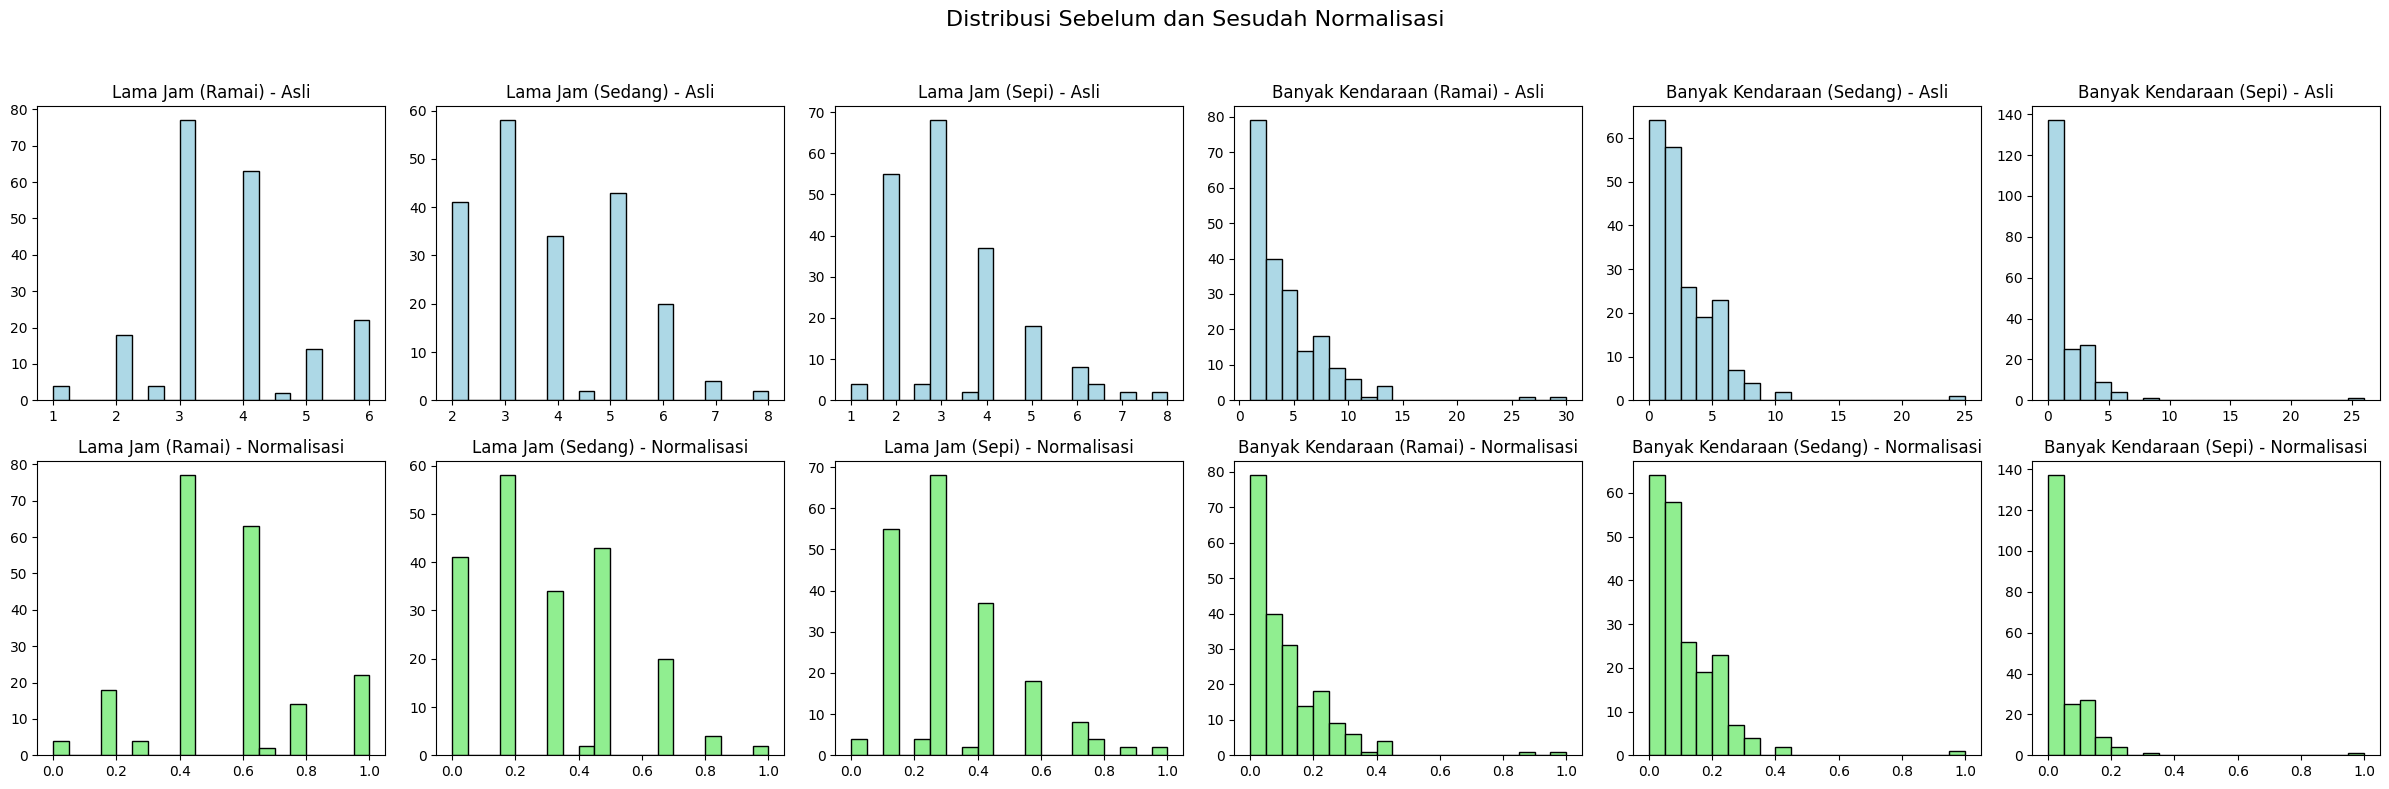

In [ ]:
print("\n=== Visualisasi Ringkas: Sebelum vs Sesudah Normalisasi ===")

# Batasi maksimal 6 kolom numerik untuk visualisasi agar tetap sederhana
kolom_visual = kolom_numerik[:6]

fig, axes = plt.subplots(2, len(kolom_visual), figsize=(4 * len(kolom_visual), 8))
fig.suptitle('Distribusi Sebelum dan Sesudah Normalisasi', fontsize=16)

for i, col in enumerate(kolom_visual):
    # Sebelum normalisasi
    axes[0, i].hist(df_original[col], bins=20, color='lightblue', edgecolor='black')
    axes[0, i].set_title(f'{col} - Asli')

    # Sesudah normalisasi
    axes[1, i].hist(df_normalized[col], bins=20, color='lightgreen', edgecolor='black')
    axes[1, i].set_title(f'{col} - Normalisasi')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# **Penerapan Fuzzy**

In [ ]:
# Siapkan data fuzzy dari hasil normalisasi sebelumnya (df_normalized)
df_fuzzy = df_normalized.copy()

print("\n=== Data Fuzzy Pemilihan ===")
display(df_fuzzy.head())


=== Data Fuzzy Pemilihan ===


,Lokasi,Jenis Kendaraan,Lama Jam (Ramai),Lama Jam (Sedang),Lama Jam (Sepi),Banyak Kendaraan (Ramai),Banyak Kendaraan (Sedang),Banyak Kendaraan (Sepi),Tarif Parkir,Total Sehari
26,toko satria,mobil,0.2,0.166667,0.285714,0.068966,0.08,0.038462,0.0,0.036145
27,toko mlati,mobil,0.2,0.166667,0.285714,0.103448,0.12,0.076923,0.0,0.080321
28,toko pagoda,mobil,0.2,0.166667,0.142857,0.172414,0.16,0.115385,0.0,0.100402
29,matahari bazzar,mobil,0.4,0.500000,0.142857,0.103448,0.12,0.076923,0.0,0.124498
32,gerai indosat,mobil,0.2,0.166667,0.285714,0.034483,0.04,0.038462,0.0,0.028112


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Buat variabel input fuzzy
lama_jam_ramai = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'lama_jam_ramai')
banyak_kendaraan_ramai = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'banyak_kendaraan_ramai')

# Output Sugeno berupa fungsi konstan atau linier, kita buat manual
# Jadi kita tidak pakai ctrl.Consequent (karena Sugeno bukan Mamdani)

# Definisikan fungsi keanggotaan (trapesium/segitiga misalnya)
lama_jam_ramai['rendah'] = fuzz.trimf(lama_jam_ramai.universe, [0, 0, 0.5])
lama_jam_ramai['sedang'] = fuzz.trimf(lama_jam_ramai.universe, [0.2, 0.5, 0.8])
lama_jam_ramai['tinggi'] = fuzz.trimf(lama_jam_ramai.universe, [0.5, 1, 1])

banyak_kendaraan_ramai['sedikit'] = fuzz.trimf(banyak_kendaraan_ramai.universe, [0, 0, 0.5])
banyak_kendaraan_ramai['sedang'] = fuzz.trimf(banyak_kendaraan_ramai.universe, [0.2, 0.5, 0.8])
banyak_kendaraan_ramai['banyak'] = fuzz.trimf(banyak_kendaraan_ramai.universe, [0.5, 1, 1])

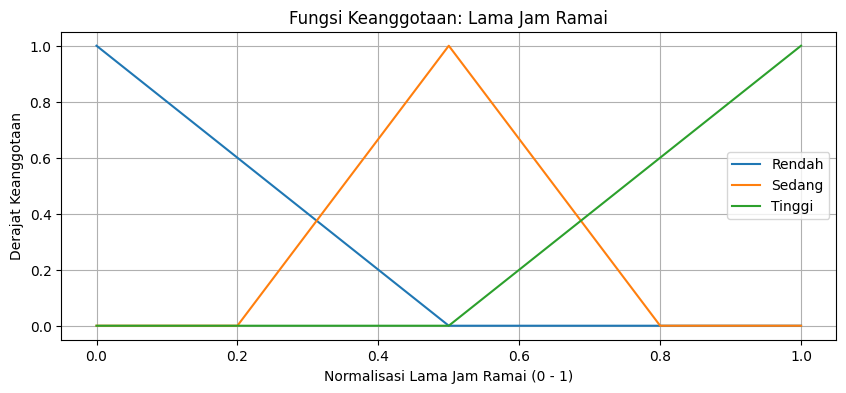

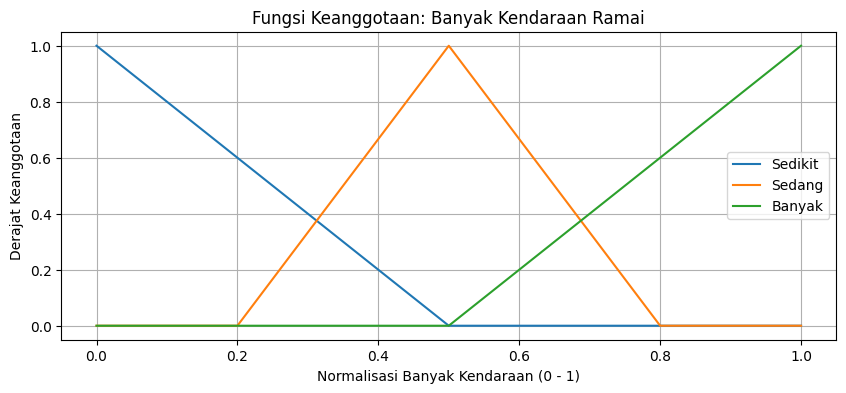

In [ ]:
import matplotlib.pyplot as plt

# Plot untuk lama_jam_ramai
plt.figure(figsize=(10, 4))
plt.plot(lama_jam_ramai.universe, lama_jam_ramai['rendah'].mf, label='Rendah')
plt.plot(lama_jam_ramai.universe, lama_jam_ramai['sedang'].mf, label='Sedang')
plt.plot(lama_jam_ramai.universe, lama_jam_ramai['tinggi'].mf, label='Tinggi')
plt.title('Fungsi Keanggotaan: Lama Jam Ramai')
plt.xlabel('Normalisasi Lama Jam Ramai (0 - 1)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True)
plt.show()

# Plot untuk banyak_kendaraan_ramai
plt.figure(figsize=(10, 4))
plt.plot(banyak_kendaraan_ramai.universe, banyak_kendaraan_ramai['sedikit'].mf, label='Sedikit')
plt.plot(banyak_kendaraan_ramai.universe, banyak_kendaraan_ramai['sedang'].mf, label='Sedang')
plt.plot(banyak_kendaraan_ramai.universe, banyak_kendaraan_ramai['banyak'].mf, label='Banyak')
plt.title('Fungsi Keanggotaan: Banyak Kendaraan Ramai')
plt.xlabel('Normalisasi Banyak Kendaraan (0 - 1)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def hitung_tarif_sugeno(lama_jam, banyak_kendaraan):
    # Derajat keanggotaan untuk masing-masing input
    μ_ljr = {
        'rendah': fuzz.interp_membership(lama_jam_ramai.universe, lama_jam_ramai['rendah'].mf, lama_jam),
        'sedang': fuzz.interp_membership(lama_jam_ramai.universe, lama_jam_ramai['sedang'].mf, lama_jam),
        'tinggi': fuzz.interp_membership(lama_jam_ramai.universe, lama_jam_ramai['tinggi'].mf, lama_jam)
    }

    μ_bkr = {
        'sedikit': fuzz.interp_membership(banyak_kendaraan_ramai.universe, banyak_kendaraan_ramai['sedikit'].mf, banyak_kendaraan),
        'sedang': fuzz.interp_membership(banyak_kendaraan_ramai.universe, banyak_kendaraan_ramai['sedang'].mf, banyak_kendaraan),
        'banyak': fuzz.interp_membership(banyak_kendaraan_ramai.universe, banyak_kendaraan_ramai['banyak'].mf, banyak_kendaraan)
    }

    # === 3. Aturan Fuzzy Sugeno + Output Konstan per rule ===
    rules = [
        # (IF lama_jam X AND banyak_kendaraan Y, THEN output = Z)
        ('rendah',  'sedikit',  0.2),
        ('rendah',  'sedang',   0.3),
        ('rendah',  'banyak',   0.4),
        ('sedang',  'sedikit',  0.4),
        ('sedang',  'sedang',   0.5),
        ('sedang',  'banyak',   0.6),
        ('tinggi',  'sedikit',  0.6),
        ('tinggi',  'sedang',   0.7),
        ('tinggi',  'banyak',   0.8),
    ]

    # === 4. Hitung total weighted average Sugeno ===
    numerator = 0
    denominator = 0

    for ljr, bkr, output in rules:
        α = min(μ_ljr[ljr], μ_bkr[bkr])  # derajat keanggotaan (AND = min)
        numerator += α * output
        denominator += α

    # Hindari pembagian nol
    if denominator == 0:
        return 0

    return numerator / denominator

In [ ]:
# Contoh input (sudah dinormalisasi)
contoh_lama = 0.7
contoh_kendaraan = 0.8

# Hitung tarif fuzzy Sugeno (0–1)
tarif_rekomendasi = hitung_tarif_sugeno(contoh_lama, contoh_kendaraan)
print(f"Tarif Rekomendasi (skala 0–1): {tarif_rekomendasi:.2f}")

# Konversi ke tarif nominal
tarif_min = 2000
tarif_max = 5000  # Ubah sesuai kebijakan

tarif_nilai_rupiah = tarif_min + tarif_rekomendasi * (tarif_max - tarif_min)
print(f"Tarif Rekomendasi (nominal): Rp{int(tarif_nilai_rupiah):,}")

Tarif Rekomendasi (skala 0–1): 0.71
Tarif Rekomendasi (nominal): Rp4,127


In [ ]:
import pandas as pd

# Contoh data dummy: DataFrame df_normalized
# Pastikan kamu punya kolom: 'Lokasi', 'Jenis Kendaraan', 'Lama Jam (Ramai)', 'Banyak Kendaraan (Ramai)'

def hitung_tarif_nominal(normalized_lama, normalized_kendaraan):
    # Hitung skor Sugeno
    skor_sugeno = hitung_tarif_sugeno(normalized_lama, normalized_kendaraan)

    # Konversi dari skala 0–1 ke nilai nominal
    tarif_min = 2000
    tarif_max = 5000
    return round(tarif_min + skor_sugeno * (tarif_max - tarif_min), 0)

# Terapkan ke semua baris
df_normalized['Tarif Parkir Ideal (Fuzzy Sugeno)'] = df_normalized.apply(
    lambda row: hitung_tarif_nominal(row['Lama Jam (Ramai)'], row['Banyak Kendaraan (Ramai)']), axis=1
)

# Pilih kolom untuk ditampilkan
hasil = df_normalized[['Lokasi', 'Jenis Kendaraan', 'Tarif Parkir Ideal (Fuzzy Sugeno)']]

# Tampilkan
print("Hasil dengan Tarif Parkir Asli dan Ideal (Fuzzy Sugeno):")
display(hasil)

Hasil dengan Tarif Parkir Asli dan Ideal (Fuzzy Sugeno):


,Lokasi,Jenis Kendaraan,Tarif Parkir Ideal (Fuzzy Sugeno)
26,toko satria,mobil,2600.0
27,toko mlati,mobil,2600.0
28,toko pagoda,mobil,2600.0
29,matahari bazzar,mobil,3062.0
32,gerai indosat,mobil,2600.0
33,toko cinderela,mobil,2600.0
34,toko daerah,mobil,2600.0
35,ko listrik kebondale,mobil,3060.0
36,bcl-toko lampu,mobil,3199.0
37,matahari store,mobil,3948.0


In [ ]:
df_normalized['Selisih Tarif'] = df_normalized['Tarif Parkir Ideal (Fuzzy Sugeno)'] - df_normalized['Tarif Parkir']

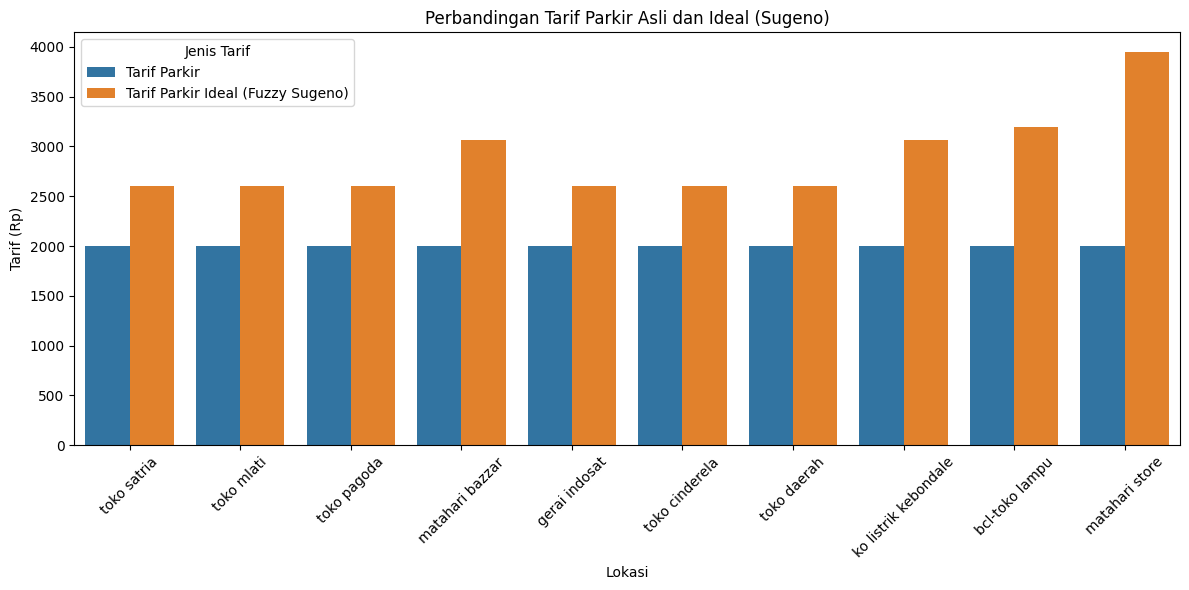

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Misal ambil data subset dulu
df_plot = df_normalized.loc[26:37, ['Lokasi', 'Tarif Parkir Ideal (Fuzzy Sugeno)']].copy()

# Tambahkan tarif parkir aktual (mobil = 2000 untuk semua)
df_plot['Tarif Parkir'] = 2000

# Ubah format dari wide ke long untuk keperluan plot
df_melted = pd.melt(
    df_plot,
    id_vars='Lokasi',
    value_vars=['Tarif Parkir', 'Tarif Parkir Ideal (Fuzzy Sugeno)'],
    var_name='Jenis Tarif',
    value_name='Nilai'
)

# Plot dengan warna dan urutan jelas
palette = {
    'Tarif Parkir': '#1f77b4',  # biru
    'Tarif Parkir Ideal (Fuzzy Sugeno)': '#ff7f0e'  # oranye
}

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted,
    x='Lokasi',
    y='Nilai',
    hue='Jenis Tarif',
    palette=palette
)
plt.title('Perbandingan Tarif Parkir Asli dan Ideal (Sugeno)')
plt.ylabel("Tarif (Rp)")
plt.xlabel("Lokasi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()